# Redes Generativas Adversarias "GANs"

## GAN

### 1. Importaciones


- `torch`: construcción y entrenamiento de las redes.
- `torchvision`: dataset MNIST y utilidades para imágenes.
- `matplotlib`: visualizaciones.
- `numpy` y `random`: reproducibilidad.
- `time`: comparar tiempos de entrenamiento.

In [53]:
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

### 2. Semilla y detección de GPU

La semilla permite que los resultados sean más reproducibles.

In [54]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda"

### 3. Configuración general del experimento

Usaremos los **mismos hiperparámetros** para las dos arquitecturas.


In [ ]:
LATENT_DIM = 100
BATCH_SIZE = 256
EPOCHS = 50
LEARNING_RATE = 2e-4

SNAPSHOT_EPOCHS = [0, 1, 5, 10, 20, 30, 40, 45, 50]

print("Dimensión del ruido:", LATENT_DIM)
print("Batch size:", BATCH_SIZE)
print("Épocas:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Dimensión del ruido: 100
Batch size: 256
Épocas: 50
Learning rate: 0.0002


### 4. Cargar MNIST

Normalizaremos los píxeles al intervalo **[-1, 1]**, porque los dos generadores terminarán con una activación `Tanh`.

In [56]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Cantidad de imágenes:", len(mnist), " forma de las imagenes: ", mnist[0][0].shape)

Cantidad de imágenes: 60000  forma de las imagenes:  torch.Size([1, 28, 28])


### 5. Crear los DataLoader

Crearemos un `DataLoader` independiente para cada modelo.

Ambos comienzan con la misma semilla de mezcla, de manera que la comparación sea lo más consistente posible.


In [57]:
def create_dataloader():
    generator = torch.Generator()
    generator.manual_seed(SEED)

    return DataLoader(
        mnist,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator
    )

gan_loader = create_dataloader()
dcgan_loader = create_dataloader()

images, labels = next(iter(gan_loader))

print("Forma de un batch de imágenes:", images.shape, images.min().item(), "a", images.max().item())

Forma de un batch de imágenes: torch.Size([256, 1, 28, 28]) -1.0 a 1.0


### 6. Visualizar imágenes reales

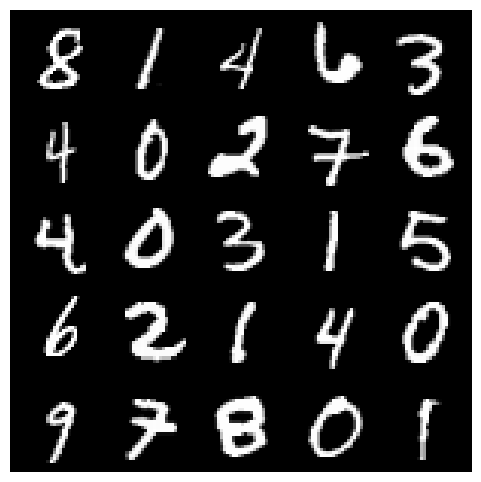

In [58]:
def show_images(images, nrow=5, max_images=25):
    images = images[:max_images].detach().cpu()

    grid = make_grid(
        images,
        nrow=nrow,
        normalize=True,
        value_range=(-1, 1),
        padding=2
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.show()

show_images(images)

## ¿Qué recibe el generador?

### 7. Ruido


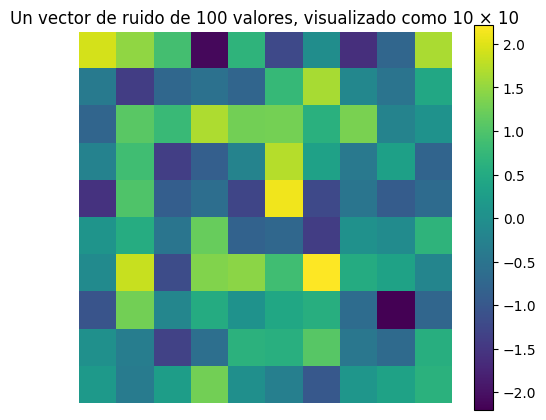

In [59]:
example_noise = torch.randn(1, LATENT_DIM)

plt.figure(figsize=(6, 5))
plt.imshow(example_noise.reshape(10, 10))
plt.title("Un vector de ruido de 100 valores, visualizado como 10 × 10")
plt.colorbar()
plt.axis("off")
plt.show()



### 8. Generador GAN

In [60]:
class MLPGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.net(z)
        return x.view(-1, 1, 28, 28)

### 9. Discriminador GAN

El discriminador recibe una imagen real o generada

In [ ]:
class MLPDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

### 10. Crear la GAN clásica

Todavía no ha aprendido nada, miremos lo que genera **antes del entrenamiento**.

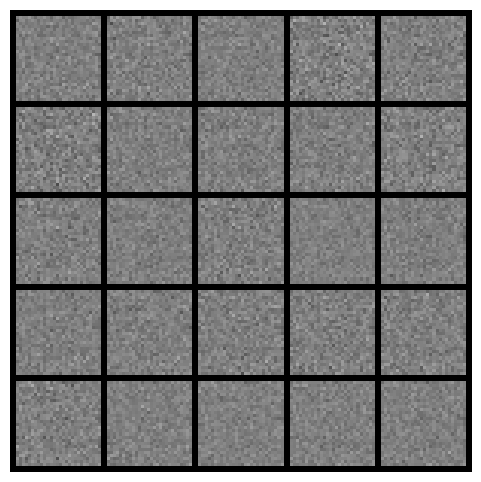

In [62]:
gan_G = MLPGenerator().to(device)
gan_D = MLPDiscriminator().to(device)

fixed_noise = torch.randn(25, LATENT_DIM, device=device)

gan_G.eval()
with torch.no_grad():
    before_gan = gan_G(fixed_noise)
gan_G.train()

show_images(before_gan, nrow=5)


## DCGAN

### 10. Generador convolucional

Las capas `ConvTranspose2d` aumentan progresivamente el tamaño espacial de la representación.

In [63]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU()
        )

        self.conv = nn.Sequential(
            nn.Unflatten(1, (128, 7, 7)),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 14x14 -> 28x28
            nn.ConvTranspose2d(
                64, 1,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        return self.conv(x)

### 11. Discriminador convolucional

Ahora el discriminador no aplana inmediatamente la imagen, primero utiliza convoluciones para extraer patrones espaciales:

`28×28 → 14×14 → 7×7 → decisión`

Esta es la diferencia conceptual más importante respecto a la GAN clásica.

In [ ]:
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(
                1, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # 14x14 -> 7x7
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.net(x)

### 13. Crear la DCGAN y ver la salida inicial


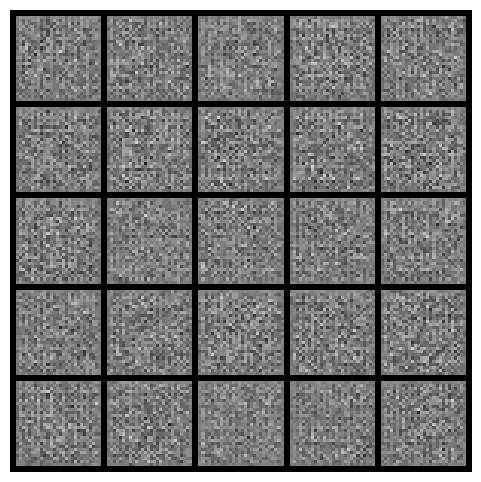

In [65]:
dcgan_G = DCGenerator().to(device)
dcgan_D = DCDiscriminator().to(device)

dcgan_G.eval()
with torch.no_grad():
    before_dcgan = dcgan_G(fixed_noise)
dcgan_G.train()

show_images(before_dcgan, nrow=5)

### 12 Entrenamiento

#### Turno 1 — entrenar al discriminador

#### Turno 2 — entrenar al generador


In [ ]:
def train_gan(
    G,
    D,
    dataloader,
    epochs=EPOCHS,
    latent_dim=LATENT_DIM,
    lr=LEARNING_RATE,
    snapshot_epochs=SNAPSHOT_EPOCHS,
    fixed_noise=fixed_noise
):
    criterion = nn.BCEWithLogitsLoss()

    optimizer_G = torch.optim.Adam(
        G.parameters(),
        lr=lr,
        betas=(0.5, 0.999)
    )

    optimizer_D = torch.optim.Adam(
        D.parameters(),
        lr=lr,
        betas=(0.5, 0.999)
    )

    history_G = []
    history_D = []
    snapshots = {}

    # Guardar estado inicial: época 0.
    G.eval()
    with torch.no_grad():
        snapshots[0] = G(fixed_noise).cpu()
    G.train()

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):

        sum_loss_G = 0.0
        sum_loss_D = 0.0

        for real_images, _ in dataloader:

            real_images = real_images.to(
                device,
                non_blocking=torch.cuda.is_available()
            )

            batch_size = real_images.size(0)

            real_targets = torch.ones(
                batch_size, 1,
                device=device
            )

            fake_targets = torch.zeros(
                batch_size, 1,
                device=device
            )

            # =====================================
            # 1) ENTRENAR DISCRIMINADOR
            # =====================================
            optimizer_D.zero_grad()

            # Imágenes reales -> objetivo 1
            real_logits = D(real_images)
            loss_D_real = criterion(
                real_logits,
                real_targets
            )

            # Imágenes falsas -> objetivo 0
            z = torch.randn(
                batch_size,
                latent_dim,
                device=device
            )

            fake_images = G(z)

            # detach() evita actualizar G en este paso.
            fake_logits = D(fake_images.detach())
            loss_D_fake = criterion(
                fake_logits,
                fake_targets
            )

            loss_D = (
                loss_D_real + loss_D_fake
            ) / 2

            loss_D.backward()
            optimizer_D.step()

            # =====================================
            # 2) ENTRENAR GENERADOR
            # =====================================
            optimizer_G.zero_grad()

            # Generamos nuevas imágenes.
            z = torch.randn(
                batch_size,
                latent_dim,
                device=device
            )

            fake_images = G(z)

            # G quiere que D crea que son reales.
            fake_logits_for_G = D(fake_images)

            loss_G = criterion(
                fake_logits_for_G,
                real_targets
            )

            loss_G.backward()
            optimizer_G.step()

            sum_loss_D += loss_D.item()
            sum_loss_G += loss_G.item()

        avg_loss_D = sum_loss_D / len(dataloader)
        avg_loss_G = sum_loss_G / len(dataloader)

        history_D.append(avg_loss_D)
        history_G.append(avg_loss_G)

        if epoch in snapshot_epochs:
            G.eval()
            with torch.no_grad():
                snapshots[epoch] = G(fixed_noise).cpu()
            G.train()

        print(
            f"Época {epoch:02d}/{epochs} | "
            f"Loss D: {avg_loss_D:.4f} | "
            f"Loss G: {avg_loss_G:.4f}"
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_time = time.perf_counter() - start_time

    return {
        "loss_G": history_G,
        "loss_D": history_D,
        "snapshots": snapshots,
        "time": elapsed_time
    }

### 15 Entrenar la GAN


In [67]:
gan_results = train_gan(
    gan_G,
    gan_D,
    gan_loader
)

print(
    "\nTiempo GAN clásica:",
    round(gan_results["time"], 2),
    "segundos"
)

Época 01/50 | Loss D: 0.5434 | Loss G: 1.0284
Época 02/50 | Loss D: 0.2830 | Loss G: 2.2849
Época 03/50 | Loss D: 0.1809 | Loss G: 3.4627
Época 04/50 | Loss D: 0.2010 | Loss G: 3.3951
Época 05/50 | Loss D: 0.1886 | Loss G: 3.6249
Época 06/50 | Loss D: 0.1982 | Loss G: 3.7480
Época 07/50 | Loss D: 0.1837 | Loss G: 3.5131
Época 08/50 | Loss D: 0.2111 | Loss G: 3.4649
Época 09/50 | Loss D: 0.2211 | Loss G: 3.3710
Época 10/50 | Loss D: 0.2011 | Loss G: 3.5685
Época 11/50 | Loss D: 0.1730 | Loss G: 3.6309
Época 12/50 | Loss D: 0.1435 | Loss G: 4.1411
Época 13/50 | Loss D: 0.1367 | Loss G: 4.3123
Época 14/50 | Loss D: 0.1349 | Loss G: 4.2858
Época 15/50 | Loss D: 0.1548 | Loss G: 4.1529
Época 16/50 | Loss D: 0.1904 | Loss G: 4.0664
Época 17/50 | Loss D: 0.2043 | Loss G: 3.6407
Época 18/50 | Loss D: 0.2065 | Loss G: 3.3277
Época 19/50 | Loss D: 0.2051 | Loss G: 3.1934
Época 20/50 | Loss D: 0.2427 | Loss G: 2.9951
Época 21/50 | Loss D: 0.2769 | Loss G: 2.9007
Época 22/50 | Loss D: 0.2500 | Los

### 16. Entrenamiento DCGAN

In [68]:
dcgan_results = train_gan(
    dcgan_G,
    dcgan_D,
    dcgan_loader
)

print(
    "\nTiempo DCGAN:",
    round(dcgan_results["time"], 2),
    "segundos"
)

Época 01/50 | Loss D: 0.1679 | Loss G: 2.9405
Época 02/50 | Loss D: 0.2518 | Loss G: 1.9127
Época 03/50 | Loss D: 0.1594 | Loss G: 2.3911
Época 04/50 | Loss D: 0.1289 | Loss G: 2.7059
Época 05/50 | Loss D: 0.1297 | Loss G: 2.7848
Época 06/50 | Loss D: 0.1466 | Loss G: 2.7570
Época 07/50 | Loss D: 0.1499 | Loss G: 2.7007
Época 08/50 | Loss D: 0.1537 | Loss G: 2.6478
Época 09/50 | Loss D: 0.1885 | Loss G: 2.5079
Época 10/50 | Loss D: 0.1839 | Loss G: 2.5321
Época 11/50 | Loss D: 0.1971 | Loss G: 2.4303
Época 12/50 | Loss D: 0.1876 | Loss G: 2.4452
Época 13/50 | Loss D: 0.2104 | Loss G: 2.3714
Época 14/50 | Loss D: 0.2102 | Loss G: 2.3937
Época 15/50 | Loss D: 0.2030 | Loss G: 2.3748
Época 16/50 | Loss D: 0.1963 | Loss G: 2.4184
Época 17/50 | Loss D: 0.1990 | Loss G: 2.4408
Época 18/50 | Loss D: 0.1934 | Loss G: 2.4629
Época 19/50 | Loss D: 0.2107 | Loss G: 2.4583
Época 20/50 | Loss D: 0.1886 | Loss G: 2.5070
Época 21/50 | Loss D: 0.2179 | Loss G: 2.4839
Época 22/50 | Loss D: 0.1898 | Los

### 17 Comparación directa


- izquierda: GAN clásica;
- derecha: DCGAN.


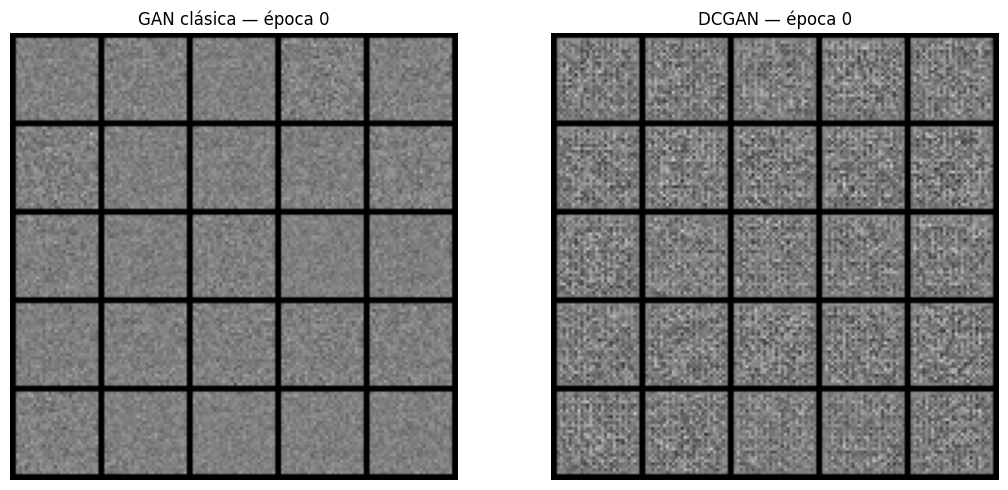

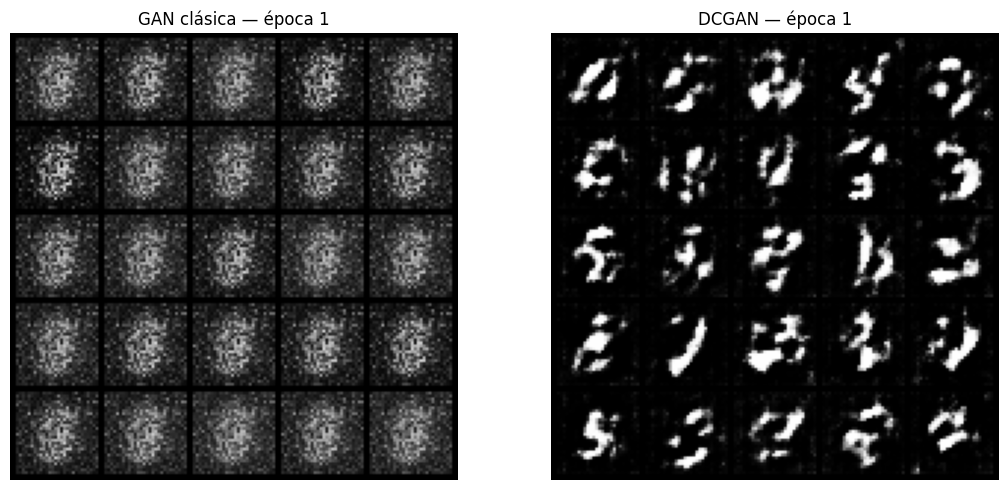

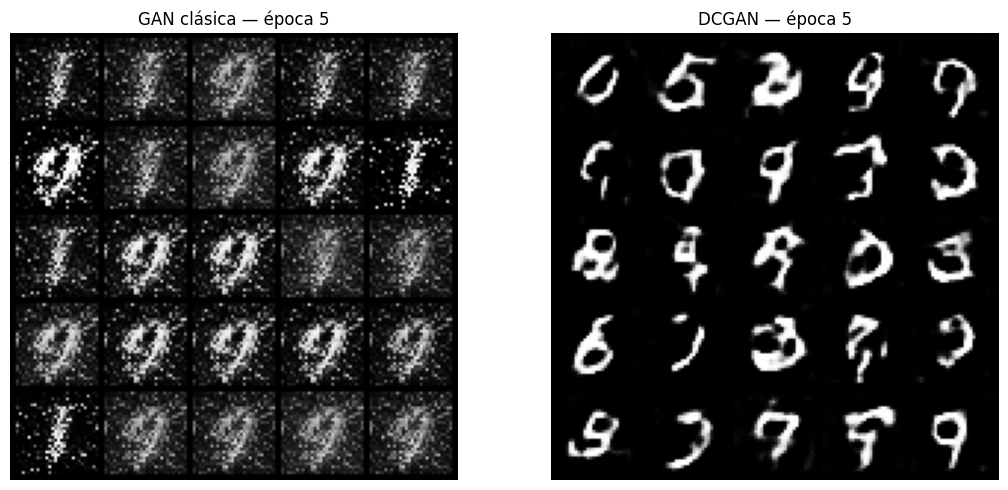

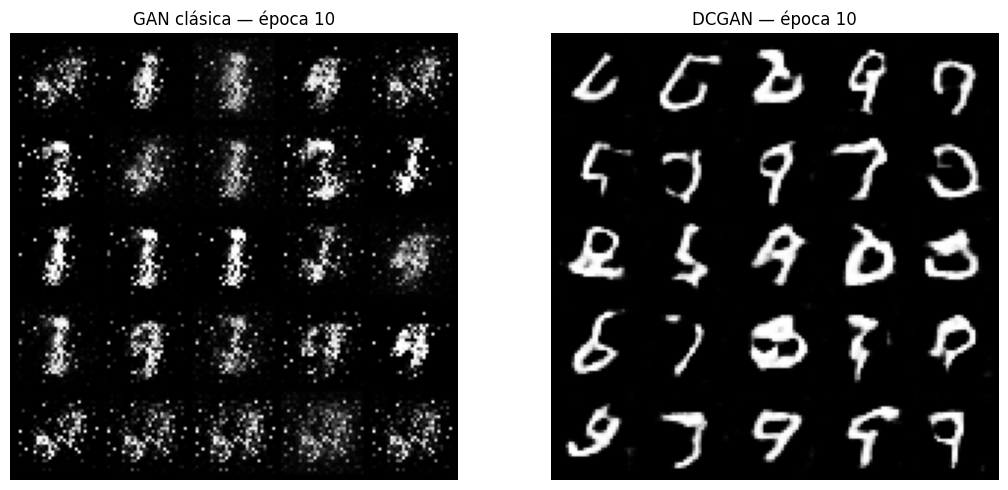

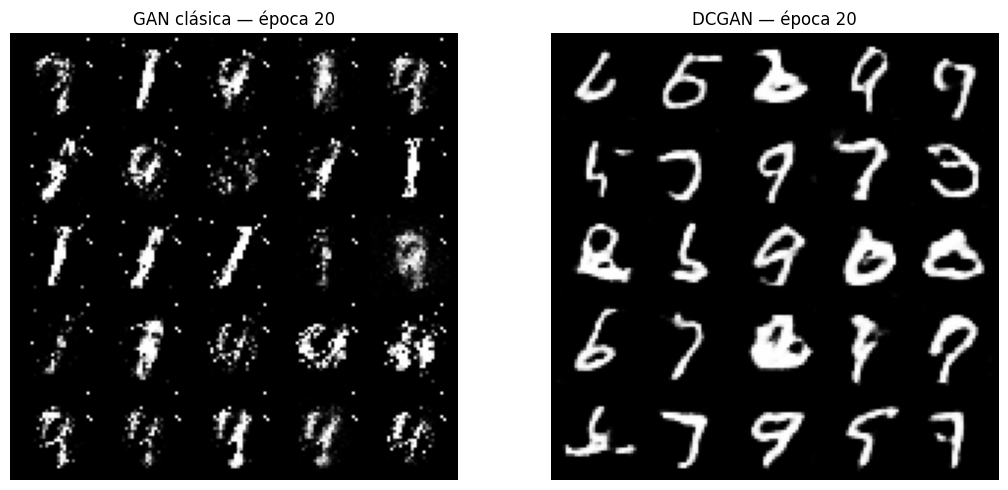

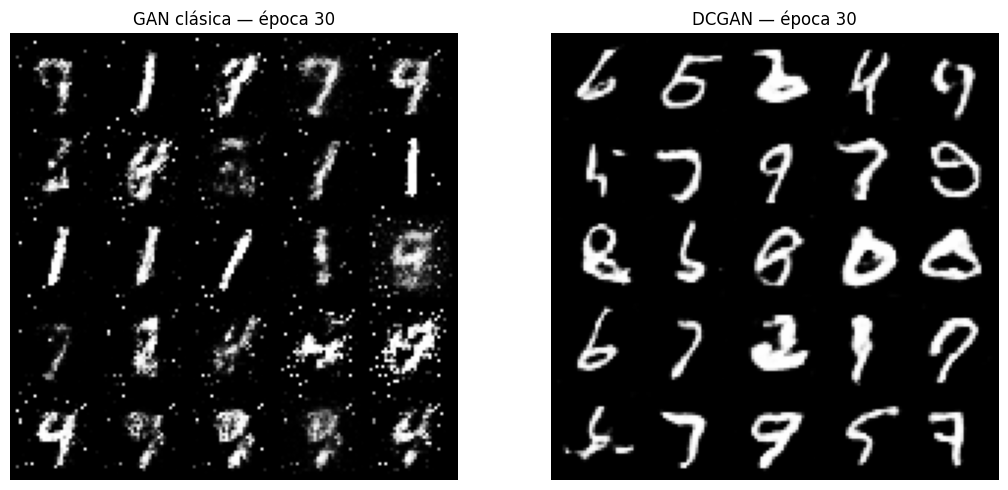

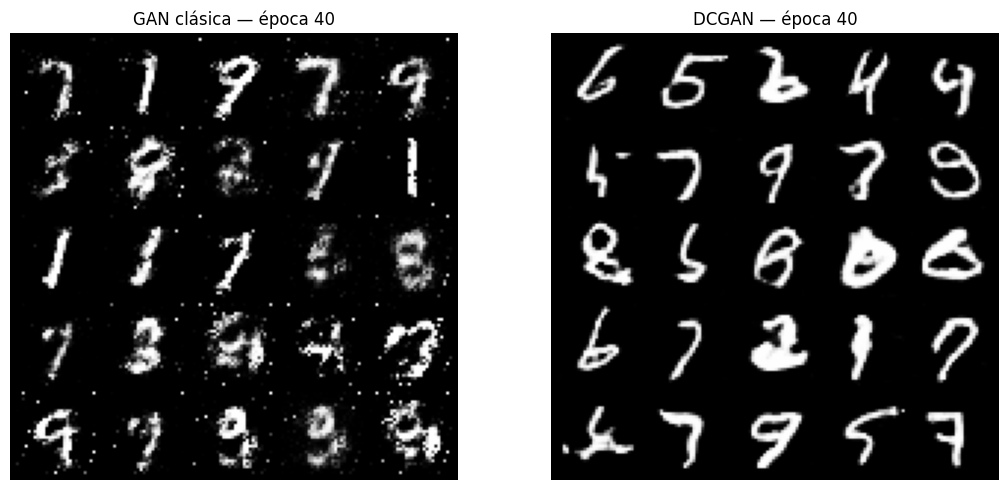

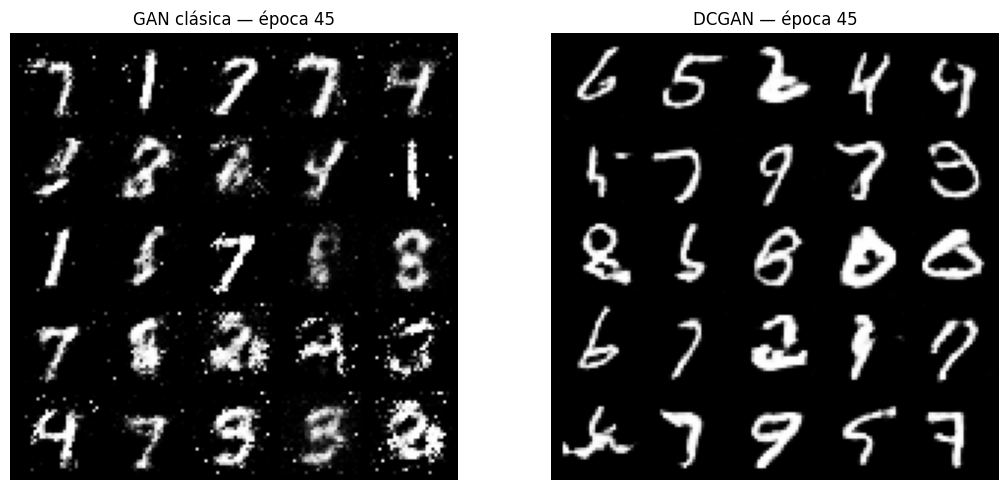

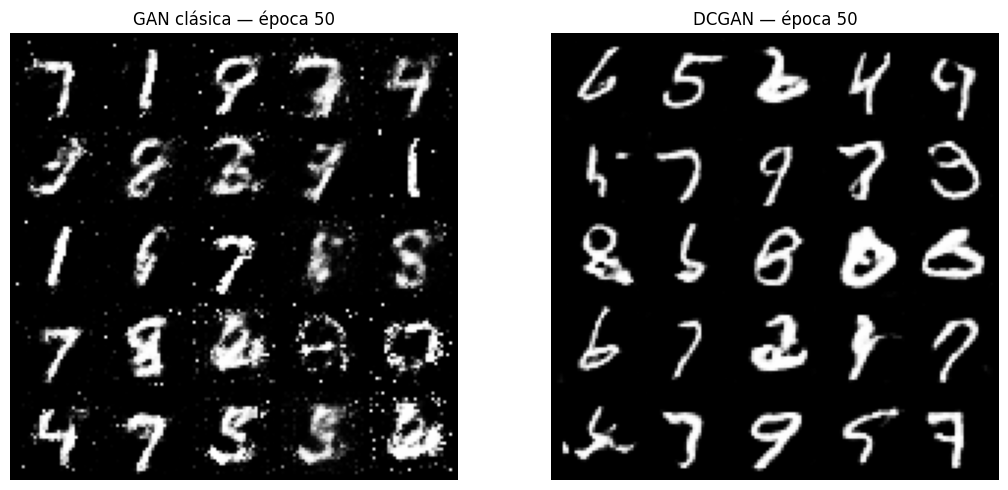

In [69]:
def compare_snapshots(
    results_a,
    results_b,
    epochs,
    title_a="GAN clásica",
    title_b="DCGAN"
):
    for epoch in epochs:
        if (
            epoch not in results_a["snapshots"]
            or epoch not in results_b["snapshots"]
        ):
            continue

        images_a = results_a["snapshots"][epoch][:25]
        images_b = results_b["snapshots"][epoch][:25]

        grid_a = make_grid(
            images_a,
            nrow=5,
            normalize=True,
            value_range=(-1, 1)
        )

        grid_b = make_grid(
            images_b,
            nrow=5,
            normalize=True,
            value_range=(-1, 1)
        )

        fig, axes = plt.subplots(1, 2, figsize=(11, 5))

        axes[0].imshow(grid_a.permute(1, 2, 0))
        axes[0].set_title(f"{title_a} — época {epoch}")
        axes[0].axis("off")

        axes[1].imshow(grid_b.permute(1, 2, 0))
        axes[1].set_title(f"{title_b} — época {epoch}")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

compare_snapshots(
    gan_results,
    dcgan_results,
    SNAPSHOT_EPOCHS
)

### 18. Comparar las pérdidas

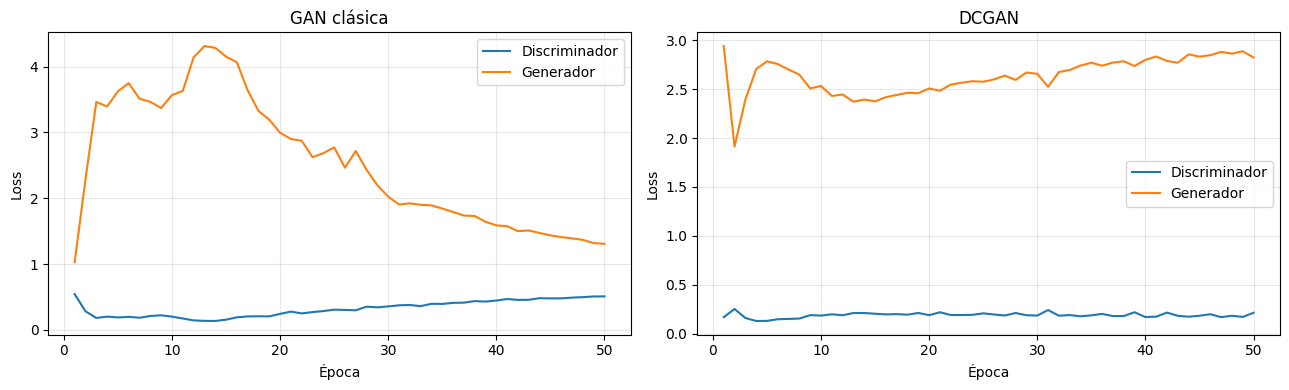

In [70]:
epochs_axis = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(
    epochs_axis,
    gan_results["loss_D"],
    label="Discriminador"
)
axes[0].plot(
    epochs_axis,
    gan_results["loss_G"],
    label="Generador"
)
axes[0].set_title("GAN clásica")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs_axis,
    dcgan_results["loss_D"],
    label="Discriminador"
)
axes[1].plot(
    epochs_axis,
    dcgan_results["loss_G"],
    label="Generador"
)
axes[1].set_title("DCGAN")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 19 Resultado final

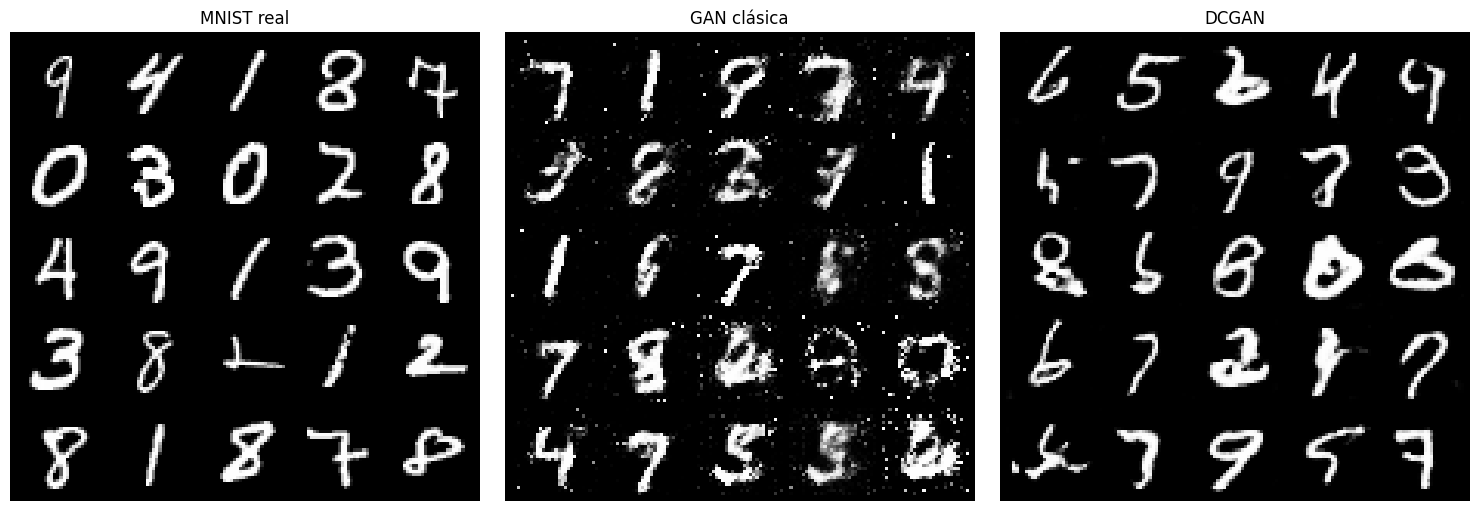

In [71]:
real_images, _ = next(iter(gan_loader))
real_images = real_images[:25]

gan_G.eval()
dcgan_G.eval()

with torch.no_grad():
    final_gan = gan_G(fixed_noise).cpu()
    final_dcgan = dcgan_G(fixed_noise).cpu()

grid_real = make_grid(
    real_images,
    nrow=5,
    normalize=True,
    value_range=(-1, 1)
)

grid_gan = make_grid(
    final_gan,
    nrow=5,
    normalize=True,
    value_range=(-1, 1)
)

grid_dcgan = make_grid(
    final_dcgan,
    nrow=5,
    normalize=True,
    value_range=(-1, 1)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(grid_real.permute(1, 2, 0))
axes[0].set_title("MNIST real")
axes[0].axis("off")

axes[1].imshow(grid_gan.permute(1, 2, 0))
axes[1].set_title("GAN clásica")
axes[1].axis("off")

axes[2].imshow(grid_dcgan.permute(1, 2, 0))
axes[2].set_title("DCGAN")
axes[2].axis("off")

plt.tight_layout()
plt.show()